# Theoretical Spike Based Z Scoring

This notebook is a **discrete, spike-focused** rewrite of the prior Z-scoring workflow.

Design rules enforced here:
- Remove continuous VAR-engine helpers based on covariance/log-determinants.
- Use discrete PID solving (`type='discrete'`) with PMFs, not Gaussian covariance matrices.
- Add Appendix-D-style discrete null generation helpers: `calculate_discrete_mi`, `sample_dirichlet_nulls`, `_numit_discrete_from_mi`.
- Enforce `k=2` subset size to avoid discrete state-space explosion.
- Enforce delayed transitions (target 15 ms) before MI/PID scoring.

In [1]:
# Setup
import io
import sys
import hashlib
from pathlib import Path
from contextlib import redirect_stdout

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import torch

try:
    DIAG_DIR = Path(globals()['__vsc_ipynb_file__']).resolve().parent
except Exception:
    DIAG_DIR = Path(r"C:\\Users\\Priya\\Desktop\\research project (SNN Info Theory)\\Project Files\\zscore_diagnostic")

PROJECT_ROOT = DIAG_DIR.parent.parent
WIMFO_ROOT = PROJECT_ROOT / 'wimfo'
CHECKPOINT_DIR_PARITY = PROJECT_ROOT / 'Project Files' / 'Checkpoints' / 'Parity'
SPK_TENSOR_DIR = DIAG_DIR / 'spk_tensors'

if str(WIMFO_ROOT) not in sys.path:
    sys.path.insert(0, str(WIMFO_ROOT))

from wimfo.W_M_Info import W_M_calculator

NETWORKS = ['2class_local_hom', '2class_fittedhet_lu']
N_NULL = 20
MAX_ATTEMPTS = 1200

# Hard loop constraint for discrete state explosion
DISCRETE_K = 2
if DISCRETE_K != 2:
    raise ValueError('This notebook is constrained to k=2 for stable discrete null fitting.')

# Delay constraint: enforce delayed transitions to reduce immediate self-correlation
OBS_DOWNSAMPLE_STRIDE = 4
TEMPORAL_DELAY_MS = 15.0

# Infer effective ms/step from training checkpoint metadata
ckpt_probe = torch.load(CHECKPOINT_DIR_PARITY / '2class_local_hom.pt', map_location='cpu')
RAW_STEP_MS = float(ckpt_probe['prms']['time_step']) * 1000.0
EFFECTIVE_STEP_MS = RAW_STEP_MS * OBS_DOWNSAMPLE_STRIDE
DELAY_STEPS = max(1, int(round(TEMPORAL_DELAY_MS / EFFECTIVE_STEP_MS)))
ACTUAL_DELAY_MS = DELAY_STEPS * EFFECTIVE_STEP_MS

print(f'Diagnostic dir      : {DIAG_DIR}')
print(f'Spike tensor dir    : {SPK_TENSOR_DIR}')
print(f'Raw step            : {RAW_STEP_MS:.3f} ms')
print(f'Effective step      : {EFFECTIVE_STEP_MS:.3f} ms (stride={OBS_DOWNSAMPLE_STRIDE})')
print(f'Delay target        : {TEMPORAL_DELAY_MS:.1f} ms')
print(f'Delay steps         : {DELAY_STEPS}')
print(f'Actual delay        : {ACTUAL_DELAY_MS:.1f} ms')

Diagnostic dir      : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\zscore_diagnostic
Spike tensor dir    : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\zscore_diagnostic\spk_tensors
Raw step            : 1.000 ms
Effective step      : 4.000 ms (stride=4)
Delay target        : 15.0 ms
Delay steps         : 4
Actual delay        : 16.0 ms


In [2]:
# Load previously extracted binary spike tensors
def load_spike_tensor(net_key):
    path = SPK_TENSOR_DIR / f'{net_key}_spk_tensor.npy'
    if not path.exists():
        raise FileNotFoundError(
            f'Missing {path}. Run the corrected extraction notebook first to generate spike tensors.'
        )
    arr = np.load(path)
    if arr.ndim != 2:
        raise ValueError(f'Expected 2D spike tensor [neurons x time], got {arr.shape}')
    is_binary = np.all((arr == 0.0) | (arr == 1.0))
    if not is_binary:
        raise ValueError(f'{net_key} spike tensor is not binary 0/1.')
    return arr.astype(np.int8, copy=False)

spike_tensors = {}
for net in NETWORKS:
    arr = load_spike_tensor(net)
    spike_tensors[net] = arr
    print(f'{net:24s} shape={arr.shape} mean_rate={arr.mean():.4f}')

2class_local_hom         shape=(32, 128000) mean_rate=0.0755
2class_fittedhet_lu      shape=(32, 128000) mean_rate=0.1490


In [3]:
# Discrete, spike-focused information helpers (no continuous VAR engine)

def _stable_seed(net_key, tensor, subset_size):
    token = f'{net_key}|{tensor}|{int(subset_size)}'.encode('utf-8')
    return int(hashlib.sha256(token).hexdigest()[:8], 16)


def _encode_states(bits):
    weights = (1 << np.arange(bits.shape[0], dtype=np.int64))[:, None]
    return np.sum(bits.astype(np.int64) * weights, axis=0)


def _decode_state(idx, k):
    return np.array([(idx >> b) & 1 for b in range(k)], dtype=np.int8)


def _mi_from_joint_table(pxy, eps=1e-12):
    pxy = np.asarray(pxy, dtype=np.float64)
    pxy = np.clip(pxy, 0.0, None)
    s = pxy.sum()
    if s <= 0:
        return np.nan
    pxy = pxy / s
    px = pxy.sum(axis=1, keepdims=True)
    py = pxy.sum(axis=0, keepdims=True)
    denom = px @ py
    mask = pxy > 0
    return float(np.sum(pxy[mask] * np.log2((pxy[mask] + eps) / (denom[mask] + eps))))


def calculate_discrete_mi(binary_matrix, delay_steps):
    """
    Build a transition PMF P(X_t, X_{t+dt}) from binary spikes and compute MI in bits.
    Implements frequency counting over discrete state transitions (Appendix D style).
    """
    x = np.asarray(binary_matrix, dtype=np.int8)
    if x.ndim != 2:
        raise ValueError('binary_matrix must be [k x time].')
    k, t = x.shape
    if t <= delay_steps:
        raise ValueError('Not enough timepoints for requested delay.')

    past = x[:, :-delay_steps]
    fut = x[:, delay_steps:]

    x_state = _encode_states(past)
    y_state = _encode_states(fut)
    n_states = 2 ** k

    counts = np.zeros((n_states, n_states), dtype=np.float64)
    np.add.at(counts, (x_state, y_state), 1.0)
    pxy = counts / counts.sum()
    mi_bits = _mi_from_joint_table(pxy)
    return mi_bits, pxy


def sample_dirichlet_nulls(rng, n_states, concentration=1.0):
    """
    Sample a random discrete source-state distribution P(X_t) from a Dirichlet prior.
    """
    alpha = np.full(int(n_states), float(concentration), dtype=np.float64)
    return rng.dirichlet(alpha)


def _logic_proxy(bits, gate):
    if gate == 'xor':
        return bits[0] ^ bits[1]
    if gate == 'or':
        return bits[0] | bits[1]
    raise ValueError(f'Unsupported gate: {gate}')


def _build_joint_from_px_logic(px, p_eps, gate, k=2):
    """
    Construct P(X_t, X_{t+dt}) from:
      1) sampled P(X_t) from Dirichlet
      2) logic-gate proxy dynamics (xor/or)
      3) independent bit-flip noise with probability p_eps
    """
    if k != 2:
        raise ValueError('Current discrete W/M wrapper requires k=2 (x1,x2,y1,y2).')

    n_states = 2 ** k
    pxy = np.zeros((n_states, n_states), dtype=np.float64)

    for x_idx in range(n_states):
        x_bits = _decode_state(x_idx, k)
        y_det = x_bits.copy()
        y_det[0] = _logic_proxy(x_bits, gate)
        y_det[1] = x_bits[0]

        for y_idx in range(n_states):
            y_bits = _decode_state(y_idx, k)
            h = np.count_nonzero(y_bits != y_det)
            p_cond = (p_eps ** h) * ((1.0 - p_eps) ** (k - h))
            pxy[x_idx, y_idx] = px[x_idx] * p_cond

    pxy = pxy / pxy.sum()

    pmf4 = np.zeros((2, 2, 2, 2), dtype=np.float64)
    for x_idx in range(n_states):
        xb = _decode_state(x_idx, k)
        for y_idx in range(n_states):
            yb = _decode_state(y_idx, k)
            pmf4[xb[0], xb[1], yb[0], yb[1]] = pxy[x_idx, y_idx]

    return pxy, pmf4


def _numit_discrete_from_mi(tdmi_target_bits, rng, k=2, tol_bits=0.02):
    """
    Discrete replacement for continuous VAR optimizer:
    - sample Dirichlet P(X_t)
    - choose random gate proxy (xor/or)
    - solve for noise flip probability p_eps so MI matches tdmi_target_bits
    """
    if k != 2:
        raise ValueError('Discrete optimizer is constrained to k=2.')

    px = sample_dirichlet_nulls(rng, n_states=2 ** k, concentration=1.0)
    gate = rng.choice(['xor', 'or'])

    def f(p_eps):
        pxy, _ = _build_joint_from_px_logic(px, p_eps=float(p_eps), gate=gate, k=k)
        return _mi_from_joint_table(pxy) - float(tdmi_target_bits)

    grid = np.linspace(0.0, 0.499, 100, dtype=np.float64)
    vals = np.array([f(p) for p in grid], dtype=np.float64)

    finite = np.isfinite(vals)
    if not np.any(finite):
        return None, None, True, np.nan, np.nan, gate

    grid = grid[finite]
    vals = vals[finite]

    nearest = int(np.argmin(np.abs(vals)))
    if abs(vals[nearest]) <= tol_bits:
        p_star = float(grid[nearest])
    else:
        p_star = None
        for i in range(len(grid) - 1):
            if vals[i] == 0.0:
                p_star = float(grid[i])
                break
            if vals[i] * vals[i + 1] < 0.0:
                try:
                    sol = root_scalar(
                        f,
                        bracket=[float(grid[i]), float(grid[i + 1])],
                        method='brentq',
                        xtol=1e-6,
                        rtol=1e-6,
                        maxiter=100,
                    )
                except Exception:
                    sol = None
                if sol is not None and sol.converged and np.isfinite(sol.root):
                    p_star = float(sol.root)
                    break

    if p_star is None:
        return None, None, True, np.nan, np.nan, gate

    pxy, pmf4 = _build_joint_from_px_logic(px, p_eps=p_star, gate=gate, k=k)
    mi_check = _mi_from_joint_table(pxy)
    if not np.isfinite(mi_check):
        return None, None, True, np.nan, np.nan, gate

    return pxy, pmf4, False, float(mi_check), float(p_star), gate


def _wm_from_discrete_pmf(joint_pmf_4d, alphabet_size=2):
    """
    Discrete PID solver path:
    - type='discrete' (not gaussian)
    - input is a joint PMF over (x1, x2, y1, y2)
    """
    with io.StringIO() as buf, redirect_stdout(buf):
        w_bits, m_bits = W_M_calculator(
            joint_pmf_4d,
            option='distr',
            type='discrete',
            alphabet_size=alphabet_size,
            unit='bits',
            verbose=False,
            optimiser='Mirror',
            options=None,
        )
    return float(w_bits), float(m_bits)


def compute_observed_wm_discrete(binary_matrix, delay_steps):
    if binary_matrix.shape[0] != 2:
        raise ValueError('Discrete wimfo wrapper expects exactly 2 source bits (k=2).')

    x1 = binary_matrix[0, :-delay_steps].astype(np.int64)
    x2 = binary_matrix[1, :-delay_steps].astype(np.int64)
    y1 = binary_matrix[0, delay_steps:].astype(np.int64)
    y2 = binary_matrix[1, delay_steps:].astype(np.int64)

    data4 = np.vstack([x1, x2, y1, y2])

    with io.StringIO() as buf, redirect_stdout(buf):
        w_bits, m_bits = W_M_calculator(
            data4,
            option='data',
            type='discrete',
            alphabet_size=2,
            unit='bits',
            verbose=False,
            optimiser='Mirror',
            options=None,
        )

    tdmi_bits, pxy = calculate_discrete_mi(binary_matrix, delay_steps=delay_steps)
    return float(w_bits), float(m_bits), float(tdmi_bits), pxy


def build_numit_discrete_null_distribution(nvar, tdmi_target_bits, n_null=20, seed=12345, max_attempts=1200):
    if int(nvar) != 2:
        raise ValueError('This notebook enforces nvar=2 for discrete null generation.')

    rng = np.random.default_rng(int(seed))
    null_m = []
    null_w = []
    model_mi_vals = []
    model_p_eps = []
    model_gate = []

    attempts = 0
    while len(null_m) < int(n_null) and attempts < int(max_attempts):
        attempts += 1

        pxy, pmf4, failed, mi_model, p_eps, gate = _numit_discrete_from_mi(
            tdmi_target_bits=tdmi_target_bits,
            rng=rng,
            k=int(nvar),
            tol_bits=0.03,
        )
        if failed:
            continue

        try:
            w_bits, m_bits = _wm_from_discrete_pmf(pmf4, alphabet_size=2)
        except Exception:
            continue

        if not (np.isfinite(w_bits) and np.isfinite(m_bits)):
            continue

        null_w.append(float(w_bits))
        null_m.append(float(m_bits))
        model_mi_vals.append(float(mi_model))
        model_p_eps.append(float(p_eps))
        model_gate.append(str(gate))

    return {
        'null_M_values': null_m,
        'null_W_values': null_w,
        'model_mi_bits': model_mi_vals,
        'model_p_eps': model_p_eps,
        'model_gate': model_gate,
        'n_null_valid': int(len(null_m)),
        'n_attempts': int(attempts),
    }


def score_observed_vs_null_m(observed_m, null_m_values):
    vals = np.asarray(null_m_values, dtype=np.float64)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return {
            'null_mean': np.nan,
            'null_std': np.nan,
            'z': np.nan,
            'p_upper': np.nan,
            'p_lower': np.nan,
            'p_two_sided': np.nan,
        }

    mu = float(vals.mean())
    sd = float(vals.std(ddof=1)) if vals.size > 1 else np.nan
    z = float((float(observed_m) - mu) / sd) if (np.isfinite(sd) and sd > 1e-12) else np.nan

    ge = np.sum(vals >= float(observed_m))
    le = np.sum(vals <= float(observed_m))
    p_upper = float((1.0 + ge) / (vals.size + 1.0))
    p_lower = float((1.0 + le) / (vals.size + 1.0))
    p_two = float(min(1.0, 2.0 * min(p_upper, p_lower)))

    return {
        'null_mean': mu,
        'null_std': sd,
        'z': z,
        'p_upper': p_upper,
        'p_lower': p_lower,
        'p_two_sided': p_two,
    }

In [4]:
# Spike-based discrete Z scoring (k=2 only, delayed transitions)
records = []

for net_key in NETWORKS:
    spk = spike_tensors[net_key]
    k = DISCRETE_K
    idx = np.linspace(0, spk.shape[0] - 1, k, dtype=int)
    sub = spk[idx, :]

    obs_w, obs_m, obs_tdmi_from_counts, obs_pxy = compute_observed_wm_discrete(
        sub,
        delay_steps=DELAY_STEPS,
    )
    tdmi_target = float(obs_w + obs_m)

    null_dist = build_numit_discrete_null_distribution(
        nvar=k,
        tdmi_target_bits=tdmi_target,
        n_null=N_NULL,
        seed=_stable_seed(net_key, 'spk', k),
        max_attempts=MAX_ATTEMPTS,
    )
    score = score_observed_vs_null_m(obs_m, null_dist['null_M_values'])

    model_mi = np.asarray(null_dist['model_mi_bits'], dtype=np.float64)
    model_p_eps = np.asarray(null_dist['model_p_eps'], dtype=np.float64)
    model_mi_mean = float(np.nanmean(model_mi)) if model_mi.size else np.nan
    model_p_eps_mean = float(np.nanmean(model_p_eps)) if model_p_eps.size else np.nan

    records.append({
        'network': net_key,
        'tensor': 'spk',
        'subset_size': k,
        'delay_steps': DELAY_STEPS,
        'delay_ms': ACTUAL_DELAY_MS,
        'observed_W_bits': obs_w,
        'observed_M_bits': obs_m,
        'observed_TDMI_bits': tdmi_target,
        'observed_TDMI_counts_bits': obs_tdmi_from_counts,
        'null_M_mean': score['null_mean'],
        'null_M_std': score['null_std'],
        'M_z_tdmi_null': score['z'],
        'M_p_upper_tdmi_null': score['p_upper'],
        'M_p_lower_tdmi_null': score['p_lower'],
        'M_p_two_sided_tdmi_null': score['p_two_sided'],
        'n_null_valid': int(null_dist['n_null_valid']),
        'n_attempts': int(null_dist['n_attempts']),
        'null_model_mi_mean': model_mi_mean,
        'null_model_p_eps_mean': model_p_eps_mean,
        'null_gate_modes': ','.join(sorted(set(null_dist['model_gate']))),
        'null_M_values': null_dist['null_M_values'],
        'null_W_values': null_dist['null_W_values'],
        'model_mi_bits': null_dist['model_mi_bits'],
        'model_p_eps': null_dist['model_p_eps'],
        'model_gate': null_dist['model_gate'],
    })

    print(f'\nScoring {net_key} / spk')
    print(f'  selected neuron idx : {idx.tolist()}')
    print(f'  delay               : {DELAY_STEPS} steps ({ACTUAL_DELAY_MS:.1f} ms)')
    print(f'  observed W,M        : {obs_w:.4f}, {obs_m:.4f} bits')
    print(f'  observed TDMI       : {tdmi_target:.4f} bits (W+M)')
    print(f'  counts TDMI         : {obs_tdmi_from_counts:.4f} bits')
    print(f'  null valid          : {null_dist["n_null_valid"]}/{N_NULL} in {null_dist["n_attempts"]} attempts')
    print(f'  z / p_upper         : {score["z"]:.3f} / {score["p_upper"]:.4f}')

scores_df = pd.DataFrame.from_records(records).sort_values(['network']).reset_index(drop=True)

show_cols = [
    'network',
    'tensor',
    'subset_size',
    'delay_steps',
    'delay_ms',
    'observed_M_bits',
    'observed_TDMI_bits',
    'null_M_mean',
    'null_M_std',
    'M_z_tdmi_null',
    'M_p_upper_tdmi_null',
    'M_p_lower_tdmi_null',
    'M_p_two_sided_tdmi_null',
    'n_null_valid',
    'n_attempts',
    'null_model_mi_mean',
    'null_model_p_eps_mean',
    'null_gate_modes',
]

print('\nScoring complete.')
display(scores_df[show_cols])

csv_path = DIAG_DIR / 'theoretical_spike_based_z_scores.csv'
scores_df.drop(
    columns=['null_M_values', 'null_W_values', 'model_mi_bits', 'model_p_eps', 'model_gate']
).to_csv(csv_path, index=False)
print(f'Saved summary CSV: {csv_path}')


Scoring 2class_local_hom / spk
  selected neuron idx : [0, 31]
  delay               : 4 steps (16.0 ms)
  observed W,M        : 0.0864, 0.0003 bits
  observed TDMI       : 0.0867 bits (W+M)
  counts TDMI         : 0.0867 bits
  null valid          : 20/20 in 20 attempts
  z / p_upper         : -2.170 / 1.0000

Scoring 2class_fittedhet_lu / spk
  selected neuron idx : [0, 31]
  delay               : 4 steps (16.0 ms)
  observed W,M        : 0.3957, 0.0526 bits
  observed TDMI       : 0.4483 bits (W+M)
  counts TDMI         : 0.4483 bits
  null valid          : 20/20 in 20 attempts
  z / p_upper         : -1.658 / 1.0000

Scoring complete.


,network,tensor,subset_size,delay_steps,delay_ms,observed_M_bits,observed_TDMI_bits,null_M_mean,null_M_std,M_z_tdmi_null,M_p_upper_tdmi_null,M_p_lower_tdmi_null,M_p_two_sided_tdmi_null,n_null_valid,n_attempts,null_model_mi_mean,null_model_p_eps_mean,null_gate_modes
0,2class_fittedhet_lu,spk,2,4,16.0,0.052602,0.448266,0.127481,0.045150,-1.658443,1.0,0.047619,0.095238,20,20,0.447122,0.182463,"or,xor"
1,2class_local_hom,spk,2,4,16.0,0.000330,0.086709,0.026384,0.012009,-2.169542,1.0,0.047619,0.095238,20,20,0.086808,0.356861,"or,xor"


Saved summary CSV: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\zscore_diagnostic\theoretical_spike_based_z_scores.csv


In [6]:
# Smoke test for subset sizes 4 and 8 via pairwise discrete projections
# ---------------------------------------------------------------------
# Why projection? The current wimfo discrete data API enforces exactly 4 rows
# (x1, x2, y1, y2), i.e. two-source systems only.
# This smoke test samples k=4 and k=8 neuron subsets, evaluates all pairwise
# 2-neuron projections inside each subset, and summarizes whether Z scores turn
# positive for any pair.

import itertools

SMOKE_SUBSET_SIZES = [4, 8]
SMOKE_REPLICATES_PER_K = 3
SMOKE_N_NULL = 10
SMOKE_MAX_ATTEMPTS = 500
SMOKE_SEED = 20260601

rng_smoke = np.random.default_rng(SMOKE_SEED)
smoke_pair_records = []
smoke_subset_records = []

for net_key in NETWORKS:
    spk = spike_tensors[net_key]
    n_neurons = spk.shape[0]

    for k_subset in SMOKE_SUBSET_SIZES:
        if k_subset > n_neurons:
            continue

        for rep in range(SMOKE_REPLICATES_PER_K):
            subset_idx = np.sort(rng_smoke.choice(n_neurons, size=k_subset, replace=False))
            z_vals = []

            for i, j in itertools.combinations(subset_idx.tolist(), 2):
                pair_mat = spk[[i, j], :]
                obs_w, obs_m, obs_tdmi_counts, _ = compute_observed_wm_discrete(
                    pair_mat,
                    delay_steps=DELAY_STEPS,
                )
                tdmi_target = float(obs_w + obs_m)

                pair_seed = _stable_seed(
                    net_key,
                    f'spk_smoke_k{k_subset}_r{rep+1}_pair{i}_{j}',
                    2,
                )
                null_dist = build_numit_discrete_null_distribution(
                    nvar=2,
                    tdmi_target_bits=tdmi_target,
                    n_null=SMOKE_N_NULL,
                    seed=pair_seed,
                    max_attempts=SMOKE_MAX_ATTEMPTS,
                )
                score = score_observed_vs_null_m(obs_m, null_dist['null_M_values'])
                z_val = float(score['z']) if np.isfinite(score['z']) else np.nan
                z_vals.append(z_val)

                smoke_pair_records.append({
                    'network': net_key,
                    'subset_size': k_subset,
                    'replicate': rep + 1,
                    'pair_i': int(i),
                    'pair_j': int(j),
                    'delay_steps': int(DELAY_STEPS),
                    'delay_ms': float(ACTUAL_DELAY_MS),
                    'observed_W_bits': float(obs_w),
                    'observed_M_bits': float(obs_m),
                    'observed_TDMI_bits': float(tdmi_target),
                    'observed_TDMI_counts_bits': float(obs_tdmi_counts),
                    'z': z_val,
                    'p_upper': float(score['p_upper']) if np.isfinite(score['p_upper']) else np.nan,
                    'n_null_valid': int(null_dist['n_null_valid']),
                    'n_attempts': int(null_dist['n_attempts']),
                })

            z_arr = np.asarray(z_vals, dtype=np.float64)
            smoke_subset_records.append({
                'network': net_key,
                'subset_size': int(k_subset),
                'replicate': int(rep + 1),
                'n_pairs': int(z_arr.size),
                'z_mean': float(np.nanmean(z_arr)) if z_arr.size else np.nan,
                'z_median': float(np.nanmedian(z_arr)) if z_arr.size else np.nan,
                'z_max': float(np.nanmax(z_arr)) if z_arr.size else np.nan,
                'z_min': float(np.nanmin(z_arr)) if z_arr.size else np.nan,
                'n_positive_z': int(np.sum(z_arr > 0)) if z_arr.size else 0,
                'positive_frac': float(np.mean(z_arr > 0)) if z_arr.size else np.nan,
            })

smoke_pairs_df = pd.DataFrame.from_records(smoke_pair_records)
smoke_subset_df = pd.DataFrame.from_records(smoke_subset_records)

smoke_overall_df = (
    smoke_pairs_df
    .groupby(['network', 'subset_size'], as_index=False)
    .agg(
        n_pairs=('z', 'size'),
        z_mean=('z', 'mean'),
        z_median=('z', 'median'),
        z_max=('z', 'max'),
        z_min=('z', 'min'),
        positive_frac=('z', lambda s: float(np.mean(np.asarray(s) > 0))),
        n_positive_z=('z', lambda s: int(np.sum(np.asarray(s) > 0))),
    )
    .sort_values(['network', 'subset_size'])
    .reset_index(drop=True)
)

print('\nSmoke test summary (pairwise projections within k=4 and k=8 subsets):')
display(smoke_overall_df)

print('\nPer-replicate subset summary:')
display(smoke_subset_df.sort_values(['network', 'subset_size', 'replicate']).reset_index(drop=True))

smoke_pairs_csv = DIAG_DIR / 'theoretical_spike_based_smoke_pairs_k4_k8.csv'
smoke_overall_csv = DIAG_DIR / 'theoretical_spike_based_smoke_summary_k4_k8.csv'

smoke_pairs_df.to_csv(smoke_pairs_csv, index=False)
smoke_overall_df.to_csv(smoke_overall_csv, index=False)

print(f'Saved pairwise smoke CSV  : {smoke_pairs_csv}')
print(f'Saved summary smoke CSV   : {smoke_overall_csv}')



Smoke test summary (pairwise projections within k=4 and k=8 subsets):


,network,subset_size,n_pairs,z_mean,z_median,z_max,z_min,positive_frac,n_positive_z
0,2class_fittedhet_lu,4,18,-1.992272,-2.087175,-1.291276,-2.671616,0.000000,0
1,2class_fittedhet_lu,8,84,-1.710340,-1.670023,0.554374,-3.822341,0.011905,1
2,2class_local_hom,4,18,-2.020466,-2.022589,-0.827332,-3.367443,0.000000,0
3,2class_local_hom,8,84,-1.964547,-1.891556,-0.172270,-3.954790,0.000000,0



Per-replicate subset summary:


,network,subset_size,replicate,n_pairs,z_mean,z_median,z_max,z_min,n_positive_z,positive_frac
0,2class_fittedhet_lu,4,1,6,-2.108109,-2.142718,-1.291276,-2.666844,0,0.000000
1,2class_fittedhet_lu,4,2,6,-1.861416,-1.668722,-1.481228,-2.671616,0,0.000000
2,2class_fittedhet_lu,4,3,6,-2.007291,-2.012505,-1.501515,-2.468729,0,0.000000
3,2class_fittedhet_lu,8,1,28,-1.883472,-1.891366,-0.807852,-2.772291,0,0.000000
4,2class_fittedhet_lu,8,2,28,-1.562791,-1.549004,-0.523439,-2.505106,0,0.000000
5,2class_fittedhet_lu,8,3,28,-1.684756,-1.585878,0.554374,-3.822341,1,0.035714
6,2class_local_hom,4,1,6,-2.014675,-1.940407,-1.062768,-2.932110,0,0.000000
7,2class_local_hom,4,2,6,-1.961446,-1.919405,-1.155001,-2.821029,0,0.000000
8,2class_local_hom,4,3,6,-2.085278,-2.133797,-0.827332,-3.367443,0,0.000000
9,2class_local_hom,8,1,28,-1.940616,-1.891162,-0.172270,-3.708546,0,0.000000


Saved pairwise smoke CSV  : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\zscore_diagnostic\theoretical_spike_based_smoke_pairs_k4_k8.csv
Saved summary smoke CSV   : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\zscore_diagnostic\theoretical_spike_based_smoke_summary_k4_k8.csv


In [7]:
# Short delay-geometry test (heterogeneous network only)
# ------------------------------------------------------
# Samples 5 random neuron pairs and sweeps delay targets 5, 15, 30, 60 ms.
# This keeps the same discrete pairwise pipeline (k=2) and checks if Z turns
# positive at specific delays.

HET_NET_KEY = '2class_fittedhet_lu'
HET_DELAY_TARGETS_MS = [5.0, 15.0, 30.0, 60.0]
HET_N_PAIRS = 5
HET_N_NULL = 10
HET_MAX_ATTEMPTS = 500
HET_SEED = 20260601

rng_het = np.random.default_rng(HET_SEED)
spk_het = spike_tensors[HET_NET_KEY]
n_neurons = spk_het.shape[0]

all_pairs = list(itertools.combinations(range(n_neurons), 2))
chosen_idx = rng_het.choice(len(all_pairs), size=min(HET_N_PAIRS, len(all_pairs)), replace=False)
chosen_pairs = [all_pairs[int(i)] for i in np.sort(chosen_idx)]

# Convert requested delays (ms) to integer steps on current effective time grid
delay_spec = []
for target_ms in HET_DELAY_TARGETS_MS:
    steps = max(1, int(round(float(target_ms) / float(EFFECTIVE_STEP_MS))))
    actual_ms = steps * float(EFFECTIVE_STEP_MS)
    delay_spec.append((float(target_ms), int(steps), float(actual_ms)))

het_pair_delay_records = []

for pair_ord, (i, j) in enumerate(chosen_pairs, start=1):
    pair_mat = spk_het[[i, j], :]

    for target_ms, delay_steps_i, actual_ms in delay_spec:
        obs_w, obs_m, obs_tdmi_counts, _ = compute_observed_wm_discrete(
            pair_mat,
            delay_steps=delay_steps_i,
        )
        tdmi_target = float(obs_w + obs_m)

        pair_seed = _stable_seed(
            HET_NET_KEY,
            f'pairdelay_pair{pair_ord}_{i}_{j}_t{int(round(target_ms))}ms',
            2,
        )
        null_dist = build_numit_discrete_null_distribution(
            nvar=2,
            tdmi_target_bits=tdmi_target,
            n_null=HET_N_NULL,
            seed=pair_seed,
            max_attempts=HET_MAX_ATTEMPTS,
        )
        score = score_observed_vs_null_m(obs_m, null_dist['null_M_values'])

        het_pair_delay_records.append({
            'network': HET_NET_KEY,
            'pair_order': int(pair_ord),
            'pair_i': int(i),
            'pair_j': int(j),
            'delay_target_ms': float(target_ms),
            'delay_steps': int(delay_steps_i),
            'delay_actual_ms': float(actual_ms),
            'observed_W_bits': float(obs_w),
            'observed_M_bits': float(obs_m),
            'observed_TDMI_bits': float(tdmi_target),
            'observed_TDMI_counts_bits': float(obs_tdmi_counts),
            'M_z_tdmi_null': float(score['z']) if np.isfinite(score['z']) else np.nan,
            'M_p_upper_tdmi_null': float(score['p_upper']) if np.isfinite(score['p_upper']) else np.nan,
            'n_null_valid': int(null_dist['n_null_valid']),
            'n_attempts': int(null_dist['n_attempts']),
        })

het_pair_delay_df = pd.DataFrame.from_records(het_pair_delay_records)
het_pair_delay_df = het_pair_delay_df.sort_values(
    ['pair_order', 'delay_target_ms']
).reset_index(drop=True)

het_delay_summary_df = (
    het_pair_delay_df
    .groupby(['delay_target_ms', 'delay_steps', 'delay_actual_ms'], as_index=False)
    .agg(
        n_pairs=('M_z_tdmi_null', 'size'),
        z_mean=('M_z_tdmi_null', 'mean'),
        z_median=('M_z_tdmi_null', 'median'),
        z_max=('M_z_tdmi_null', 'max'),
        z_min=('M_z_tdmi_null', 'min'),
        n_positive_z=('M_z_tdmi_null', lambda s: int(np.sum(np.asarray(s) > 0))),
        positive_frac=('M_z_tdmi_null', lambda s: float(np.mean(np.asarray(s) > 0))),
    )
    .sort_values('delay_target_ms')
    .reset_index(drop=True)
)

print(f'\nHeterogeneous network test: {HET_NET_KEY}')
print(f'Chosen pairs ({len(chosen_pairs)}): {chosen_pairs}')
print('\nDelay mapping (target -> actual):')
for target_ms, delay_steps_i, actual_ms in delay_spec:
    print(f'  {target_ms:5.1f} ms -> {delay_steps_i:2d} steps -> {actual_ms:5.1f} ms')

print('\nPer-delay summary across 5 sampled pairs:')
display(het_delay_summary_df)

print('\nPer-pair x delay details:')
display(het_pair_delay_df)

z_pivot = het_pair_delay_df.pivot(index='pair_order', columns='delay_target_ms', values='M_z_tdmi_null')
print('\nZ-score pivot (rows=pairs, cols=delay target ms):')
display(z_pivot)

het_pair_csv = DIAG_DIR / 'theoretical_spike_based_hetero_pair_delay_sweep.csv'
het_summary_csv = DIAG_DIR / 'theoretical_spike_based_hetero_delay_summary.csv'

het_pair_delay_df.to_csv(het_pair_csv, index=False)
het_delay_summary_df.to_csv(het_summary_csv, index=False)

print(f'Saved detailed CSV: {het_pair_csv}')
print(f'Saved summary CSV : {het_summary_csv}')


Heterogeneous network test: 2class_fittedhet_lu
Chosen pairs (5): [(0, 15), (4, 12), (7, 16), (15, 29), (25, 26)]

Delay mapping (target -> actual):
    5.0 ms ->  1 steps ->   4.0 ms
   15.0 ms ->  4 steps ->  16.0 ms
   30.0 ms ->  8 steps ->  32.0 ms
   60.0 ms -> 15 steps ->  60.0 ms

Per-delay summary across 5 sampled pairs:


,delay_target_ms,delay_steps,delay_actual_ms,n_pairs,z_mean,z_median,z_max,z_min,n_positive_z,positive_frac
0,5.0,1,4.0,5,-1.424167,-1.612700,0.002481,-2.118317,1,0.2
1,15.0,4,16.0,5,-1.324204,-1.569568,0.066559,-1.806210,1,0.2
2,30.0,8,32.0,5,-1.438566,-1.433444,0.024011,-2.739503,1,0.2
3,60.0,15,60.0,5,-1.463559,-1.365851,-0.376785,-2.819473,0,0.0



Per-pair x delay details:


,network,pair_order,pair_i,pair_j,delay_target_ms,delay_steps,delay_actual_ms,observed_W_bits,observed_M_bits,observed_TDMI_bits,observed_TDMI_counts_bits,M_z_tdmi_null,M_p_upper_tdmi_null,n_null_valid,n_attempts
0,2class_fittedhet_lu,1,0,15,5.0,1,4.0,0.227292,8.931217e-02,0.316605,0.316605,0.002481,0.545455,10,10
1,2class_fittedhet_lu,1,0,15,15.0,4,16.0,0.253244,7.192484e-02,0.325169,0.325169,0.066559,0.454545,10,10
2,2class_fittedhet_lu,1,0,15,30.0,8,32.0,0.223089,6.665479e-02,0.289744,0.289744,0.024011,0.545455,10,10
3,2class_fittedhet_lu,1,0,15,60.0,15,60.0,0.162997,4.928799e-02,0.212285,0.212285,-0.376785,0.636364,10,10
4,2class_fittedhet_lu,2,4,12,5.0,1,4.0,0.132552,0.000000e+00,0.132552,0.132552,-2.004947,1.000000,10,10
5,2class_fittedhet_lu,2,4,12,15.0,4,16.0,0.120006,0.000000e+00,0.120006,0.120006,-1.806210,1.000000,10,10
6,2class_fittedhet_lu,2,4,12,30.0,8,32.0,0.100195,0.000000e+00,0.100195,0.100195,-2.739503,1.000000,10,10
7,2class_fittedhet_lu,2,4,12,60.0,15,60.0,0.062538,0.000000e+00,0.062538,0.062538,-2.819473,1.000000,10,10
8,2class_fittedhet_lu,3,7,16,5.0,1,4.0,0.008512,0.000000e+00,0.008512,0.008512,-1.387352,1.000000,10,10
9,2class_fittedhet_lu,3,7,16,15.0,4,16.0,0.005280,0.000000e+00,0.005280,0.005280,-1.569568,1.000000,10,10



Z-score pivot (rows=pairs, cols=delay target ms):


delay_target_ms,5.0,15.0,30.0,60.0
pair_order,,,,
1,0.002481,0.066559,0.024011,-0.376785
2,-2.004947,-1.806210,-2.739503,-2.819473
3,-1.387352,-1.569568,-1.433444,-1.365851
4,-2.118317,-1.742855,-1.619547,-1.551780
5,-1.612700,-1.568946,-1.424349,-1.203905


Saved detailed CSV: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\zscore_diagnostic\theoretical_spike_based_hetero_pair_delay_sweep.csv
Saved summary CSV : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\zscore_diagnostic\theoretical_spike_based_hetero_delay_summary.csv


In [9]:
# Compatibility alias for helper functions that reference `device`
device = DEVICE
print(f'Using device alias: {device}')

Using device alias: cuda


In [10]:
# 4-class networks short smoke (auto-create spike tensors if missing)
# -----------------------------------------------------------------
# Interprets "all class" here as the available 4-class checkpoints:
#   - 4class_local_hom
#   - 4class_fittedhet_loguniform

import importlib
import itertools
import torch

PAPER_ROOT = PROJECT_ROOT / 'neural_heterogeneity' / 'SuGD_code'
if str(PAPER_ROOT) not in sys.path:
    sys.path.insert(0, str(PAPER_ROOT))

RSNN = importlib.import_module('model').RSNN
from data_gen import open_file

ALLCLASS_CHECKPOINT_MAP = {
    '4class_local_hom':    CHECKPOINT_DIR_PARITY / '4class_local_hom.pt',
    '4class_fittedhet_lu': CHECKPOINT_DIR_PARITY / '4class_fittedhet_loguniform.pt',
}

ALLCLASS_MAX_BATCHES = 2
ALLCLASS_PAIRS_PER_NET = 3
ALLCLASS_N_NULL = 10
ALLCLASS_MAX_ATTEMPTS = 500
ALLCLASS_SEED = 20260603

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def load_checkpoint_model(ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    prms = dict(ckpt['prms'])
    prms['dtype'] = torch.float
    prms['device'] = device
    prms['cuda'] = device.type == 'cuda'
    model = RSNN(prms, rec=True).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, prms


@torch.no_grad()
def collect_spk_tensor(model, prms, shd_test_path, max_batches=2, downsample_stride=4):
    stride = max(int(downsample_stride), 1)
    nb_hidden = int(model.network[0].output_size)

    raw_units, raw_times, raw_labels = open_file(str(shd_test_path))
    try:
        units = list(raw_units[:])
        times = list(raw_times[:])
        labels = np.array(raw_labels[:])
    finally:
        raw_units._v_file.close()

    batch_size = int(prms['batch_size'])
    nb_steps = int(prms['nb_steps'])
    nb_inputs = int(prms['nb_inputs'])
    inv_dt = 1.0 / float(prms['time_step'])
    class_list = prms['class_list']

    sample_index = np.where(np.isin(labels, class_list))[0]
    n_batches = min(int(max_batches), -(-len(sample_index) // batch_size))

    chunks = []
    for bidx in range(n_batches):
        batch_index = sample_index[
            batch_size * bidx : min(len(sample_index), batch_size * (bidx + 1))
        ]
        actual_bs = len(batch_index)

        t_arrays = [np.round(times[idx] * inv_dt).astype(np.int64) for idx in batch_index]
        u_arrays = [units[idx] for idx in batch_index]
        lengths = np.array([len(a) for a in t_arrays], dtype=np.int64)

        if lengths.sum():
            all_ts = np.concatenate(t_arrays)
            all_us = np.concatenate(u_arrays)
            all_bc = np.repeat(np.arange(actual_bs, dtype=np.int64), lengths)
            valid = all_ts < nb_steps
            all_ts, all_us, all_bc = all_ts[valid], all_us[valid], all_bc[valid]
            i = torch.from_numpy(np.stack([all_bc, all_ts, all_us]))
            v = torch.ones(all_ts.size, dtype=torch.float32)
            X_batch = torch.sparse_coo_tensor(
                i, v, torch.Size([actual_bs, nb_steps, nb_inputs])
            ).to_dense()
        else:
            X_batch = torch.zeros(actual_bs, nb_steps, nb_inputs)

        X_batch = X_batch.clamp(max=1.0).to(device)
        layer_recs = model(0, 0, X_batch)
        spk = layer_recs[0][2]  # spk_rec
        spk = spk[:, ::stride, :].detach().cpu().numpy()
        spk = np.transpose(spk, (2, 0, 1)).reshape(nb_hidden, -1)
        chunks.append(spk)

    return np.concatenate(chunks, axis=1).astype(np.int8)


allclass_spike_tensors = {}

for net_key, ckpt_path in ALLCLASS_CHECKPOINT_MAP.items():
    npy_path = SPK_TENSOR_DIR / f'{net_key}_spk_tensor.npy'

    if npy_path.exists():
        arr = np.load(npy_path)
        arr = arr.astype(np.int8, copy=False)
        print(f'{net_key}: loaded existing spike tensor {arr.shape} from {npy_path.name}')
    else:
        if not ckpt_path.exists():
            raise FileNotFoundError(f'Missing checkpoint: {ckpt_path}')

        model, prms = load_checkpoint_model(ckpt_path, DEVICE)
        shd_test_path = PROJECT_ROOT / 'data' / 'shd' / 'shd_test.h5'
        arr = collect_spk_tensor(
            model,
            prms,
            shd_test_path,
            max_batches=ALLCLASS_MAX_BATCHES,
            downsample_stride=OBS_DOWNSAMPLE_STRIDE,
        )
        np.save(npy_path, arr.astype(np.int8))
        print(f'{net_key}: created and saved spike tensor {arr.shape} to {npy_path.name}')

    is_binary = np.all((arr == 0) | (arr == 1))
    if not is_binary:
        raise ValueError(f'{net_key}: spike tensor is not binary.')
    allclass_spike_tensors[net_key] = arr


rng_allclass = np.random.default_rng(ALLCLASS_SEED)
allclass_records = []

for net_key, spk in allclass_spike_tensors.items():
    n_neurons = spk.shape[0]
    all_pairs = list(itertools.combinations(range(n_neurons), 2))
    n_pick = min(ALLCLASS_PAIRS_PER_NET, len(all_pairs))
    pick_idx = np.sort(rng_allclass.choice(len(all_pairs), size=n_pick, replace=False))
    chosen_pairs = [all_pairs[int(i)] for i in pick_idx]

    print(f'\nScoring {net_key} with {n_pick} random pairs (delay={DELAY_STEPS} steps, {ACTUAL_DELAY_MS:.1f} ms)')

    for pair_ord, (i, j) in enumerate(chosen_pairs, start=1):
        pair_data = spk[[i, j], :]
        obs_w, obs_m, obs_tdmi_counts, _ = compute_observed_wm_discrete(
            pair_data,
            delay_steps=DELAY_STEPS,
        )
        tdmi_target = float(obs_w + obs_m)

        pair_seed = _stable_seed(net_key, f'allclass_pair_{i}_{j}', 2)
        null_dist = build_numit_discrete_null_distribution(
            nvar=2,
            tdmi_target_bits=tdmi_target,
            n_null=ALLCLASS_N_NULL,
            seed=pair_seed,
            max_attempts=ALLCLASS_MAX_ATTEMPTS,
        )
        score = score_observed_vs_null_m(obs_m, null_dist['null_M_values'])

        rec = {
            'network': net_key,
            'pair_order': int(pair_ord),
            'pair_i': int(i),
            'pair_j': int(j),
            'delay_steps': int(DELAY_STEPS),
            'delay_ms': float(ACTUAL_DELAY_MS),
            'observed_W_bits': float(obs_w),
            'observed_M_bits': float(obs_m),
            'observed_TDMI_bits': float(tdmi_target),
            'observed_TDMI_counts_bits': float(obs_tdmi_counts),
            'M_z_tdmi_null': float(score['z']) if np.isfinite(score['z']) else np.nan,
            'M_p_upper_tdmi_null': float(score['p_upper']) if np.isfinite(score['p_upper']) else np.nan,
            'n_null_valid': int(null_dist['n_null_valid']),
            'n_attempts': int(null_dist['n_attempts']),
        }
        allclass_records.append(rec)

        print(
            f'  pair {pair_ord}: ({i},{j}) | '
            f'W={rec["observed_W_bits"]:.4f}, M={rec["observed_M_bits"]:.4f}, '
            f'z={rec["M_z_tdmi_null"]:.3f}, p_upper={rec["M_p_upper_tdmi_null"]:.4f}'
        )

allclass_df = pd.DataFrame.from_records(allclass_records)

allclass_summary_df = (
    allclass_df
    .groupby('network', as_index=False)
    .agg(
        n_pairs=('M_z_tdmi_null', 'size'),
        z_mean=('M_z_tdmi_null', 'mean'),
        z_median=('M_z_tdmi_null', 'median'),
        z_max=('M_z_tdmi_null', 'max'),
        z_min=('M_z_tdmi_null', 'min'),
        n_positive_z=('M_z_tdmi_null', lambda s: int(np.sum(np.asarray(s) > 0))),
        positive_frac=('M_z_tdmi_null', lambda s: float(np.mean(np.asarray(s) > 0))),
    )
    .sort_values('network')
    .reset_index(drop=True)
)

print('\nAll-class short smoke summary:')
display(allclass_summary_df)

print('\nAll-class pair details:')
display(allclass_df.sort_values(['network', 'pair_order']).reset_index(drop=True))

allclass_detail_csv = DIAG_DIR / 'theoretical_spike_based_allclass_pair_smoke.csv'
allclass_summary_csv = DIAG_DIR / 'theoretical_spike_based_allclass_summary_smoke.csv'
allclass_df.to_csv(allclass_detail_csv, index=False)
allclass_summary_df.to_csv(allclass_summary_csv, index=False)

print(f'Saved all-class detail CSV : {allclass_detail_csv}')
print(f'Saved all-class summary CSV: {allclass_summary_csv}')

4class_local_hom: created and saved spike tensor (32, 128000) to 4class_local_hom_spk_tensor.npy
4class_fittedhet_lu: created and saved spike tensor (32, 128000) to 4class_fittedhet_lu_spk_tensor.npy

Scoring 4class_local_hom with 3 random pairs (delay=4 steps, 16.0 ms)
  pair 1: (10,18) | W=0.2402, M=0.0044, z=-2.781, p_upper=1.0000
  pair 2: (11,14) | W=0.0045, M=0.0000, z=-1.531, p_upper=1.0000
  pair 3: (11,27) | W=0.0116, M=0.0000, z=-1.550, p_upper=1.0000

Scoring 4class_fittedhet_lu with 3 random pairs (delay=4 steps, 16.0 ms)
  pair 1: (0,20) | W=0.1153, M=0.0000, z=-2.720, p_upper=1.0000
  pair 2: (12,20) | W=0.4467, M=0.0300, z=-1.802, p_upper=1.0000
  pair 3: (13,25) | W=0.4427, M=0.0202, z=-2.564, p_upper=1.0000

All-class short smoke summary:


,network,n_pairs,z_mean,z_median,z_max,z_min,n_positive_z,positive_frac
0,4class_fittedhet_lu,3,-2.361805,-2.564137,-1.801744,-2.719535,0,0.0
1,4class_local_hom,3,-1.954158,-1.550424,-1.531297,-2.780753,0,0.0



All-class pair details:


,network,pair_order,pair_i,pair_j,delay_steps,delay_ms,observed_W_bits,observed_M_bits,observed_TDMI_bits,observed_TDMI_counts_bits,M_z_tdmi_null,M_p_upper_tdmi_null,n_null_valid,n_attempts
0,4class_fittedhet_lu,1,0,20,4,16.0,0.115255,0.000000,0.115255,0.115255,-2.719535,1.0,10,10
1,4class_fittedhet_lu,2,12,20,4,16.0,0.446694,0.030036,0.476730,0.476730,-1.801744,1.0,10,10
2,4class_fittedhet_lu,3,13,25,4,16.0,0.442718,0.020221,0.462938,0.462938,-2.564137,1.0,10,10
3,4class_local_hom,1,10,18,4,16.0,0.240161,0.004356,0.244517,0.244517,-2.780753,1.0,10,10
4,4class_local_hom,2,11,14,4,16.0,0.004535,0.000000,0.004535,0.004535,-1.531297,1.0,10,10
5,4class_local_hom,3,11,27,4,16.0,0.011607,0.000000,0.011607,0.011607,-1.550424,1.0,10,10


Saved all-class detail CSV : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\zscore_diagnostic\theoretical_spike_based_allclass_pair_smoke.csv
Saved all-class summary CSV: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\zscore_diagnostic\theoretical_spike_based_allclass_summary_smoke.csv


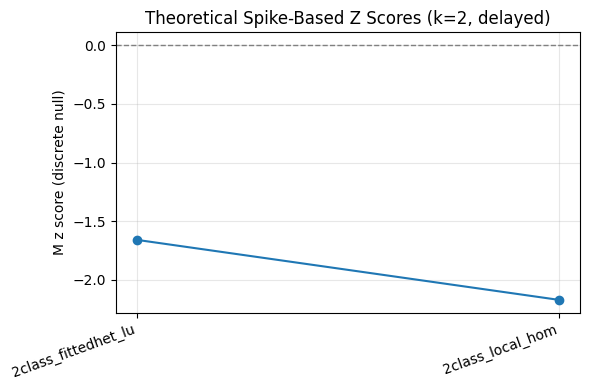

Saved plot: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\zscore_diagnostic\theoretical_spike_based_zscores.png


In [5]:
# Quick visual summary
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(scores_df['network'], scores_df['M_z_tdmi_null'], marker='o')
ax.axhline(0.0, color='gray', linewidth=1, linestyle='--')
ax.set_ylabel('M z score (discrete null)')
ax.set_title('Theoretical Spike-Based Z Scores (k=2, delayed)')
ax.grid(alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
outp = DIAG_DIR / 'theoretical_spike_based_zscores.png'
plt.savefig(outp, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved plot: {outp}')